# 单隐藏层 MLP

## 1. 为什么 XOR 问题需要隐藏层？

XOR（异或）逻辑门的真值表如下：

| x1  | x2  | y   |
|-----|-----|-----|
| 0   | 0   | 0   |
| 0   | 1   | 1   |
| 1   | 0   | 1   |
| 1   | 1   | 0   |

如果把输入 `(x1, x2)` 画在平面上，0 和 1 两个类别无法用一条直线分开（线性不可分）。  
单层感知机（无隐藏层）只能解决线性可分问题，而增加一个隐藏层后，网络可以学习到非线性的决策边界。

---

## 2. 网络结构

- **输入层**：2 个神经元，分别接收 `x1` 和 `x2`。
- **隐藏层**：2 个神经元，每个神经元使用 **Sigmoid 激活函数**（输出范围 (0,1)）。
- **输出层**：1 个神经元，也使用 Sigmoid 激活函数，输出一个概率值 `ŷ`，表示输入属于类别 1 的概率（通常大于 0.5 判为 1）。

---

## 3. 前向传播（Forward Propagation）

设输入向量 $x = [x1, x2]^T$。

### 隐藏层计算

权重矩阵 `W1` 尺寸为 `(2, 2)`，偏置向量 `b1` 尺寸为 `(2, 1)`：

$$
\mathbf{h}_{\text{raw}} = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1
$$

其中：

$$
\mathbf{W}_1 = \begin{bmatrix} w_{11}^{(1)} & w_{12}^{(1)} \\ w_{21}^{(1)} & w_{22}^{(1)} \end{bmatrix},
\quad \mathbf{b}_1 = \begin{bmatrix} b_1^{(1)} \\ b_2^{(1)} \end{bmatrix}
$$

然后经过 Sigmoid 激活函数（逐元素）：

$$
\mathbf{h} = \sigma(\mathbf{h}_{\text{raw}}) = \begin{bmatrix} \sigma(h_{\text{raw},1}) \\ \sigma(h_{\text{raw},2}) \end{bmatrix}
$$

Sigmoid 函数定义：

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

### 输出层计算

输出层权重矩阵 `W2` 尺寸为 `(1, 2)`，偏置 `b2` 是一个标量：

$$
\hat{y}_{\text{raw}} = \mathbf{W}_2 \mathbf{h} + b_2
$$

再经过 Sigmoid 得到最终输出：

$$
\hat{y} = \sigma(\hat{y}_{\text{raw}})
$$

此时 `ŷ` 是 (0,1) 之间的一个实数，可以理解为样本属于正类（y=1）的概率。

---

## 4. 损失函数（二分类交叉熵）

对于单个样本 `(x, y)`，其中 `y` 是真实标签（0 或 1），损失函数为：

$$
L = - \left[ y \log \hat{y} + (1 - y) \log (1 - \hat{y}) \right]
$$

- 如果 `y = 1`，损失为 `-log(ŷ)`，希望 ŷ 尽量接近 1。
- 如果 `y = 0`，损失为 `-log(1-ŷ)`，希望 ŷ 尽量接近 0。

整个训练集上的总损失通常是各样本损失的平均（或求和）。

---

## 5. 反向传播（Backpropagation）

反向传播的目标是：**计算损失函数关于每个可训练参数（W1, b1, W2, b2）的梯度**，然后用梯度下降法更新参数。  
核心工具：**链式法则**。

我们从输出层向输入层逐层推导。

### 5.1 输出层的梯度

记输出层线性部分为：

$$
z_2 = \mathbf{W}_2 \mathbf{h} + b_2, \quad \hat{y} = \sigma(z_2)
$$

首先计算损失对 `z2` 的导数：

$$
\frac{\partial L}{\partial z_2} = \frac{\partial L}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z_2}
$$

已知：

$$
\frac{\partial L}{\partial \hat{y}} = - \left( \frac{y}{\hat{y}} - \frac{1-y}{1-\hat{y}} \right) = \frac{\hat{y} - y}{\hat{y}(1-\hat{y})}
$$

而 Sigmoid 的导数：
$$
\frac{\partial \hat{y}}{\partial z_2} = \hat{y}(1-\hat{y})
$$

两者相乘，得到非常简洁的结果：

$$
\delta_2 = \frac{\partial L}{\partial z_2} = \hat{y} - y
$$

这个 `δ2` 是输出层线性输出的误差项。

然后：

- 对 `W2` 的梯度：

$$
\frac{\partial L}{\partial \mathbf{W}_2} = \delta_2 \cdot \mathbf{h}^T
$$

因为 `z2 = W2 * h + b2`，所以梯度是 `δ2` 与 `h` 的外积。注意这里 `W2` 是行向量（1×2），`h` 是列向量（2×1），结果是一个行向量（1×2）。

- 对 `b2` 的梯度：

$$
\frac{\partial L}{\partial b_2} = \delta_2
$$

### 5.2 隐藏层的梯度

现在误差要反向传播到隐藏层。先求损失对隐藏层输出 `h` 的梯度：

$$
\frac{\partial L}{\partial \mathbf{h}} = \mathbf{W}_2^T \cdot \delta_2
$$

因为 `z2 = W2 * h + b2`，所以 
$$
\frac{∂L}{∂h} = (\frac{∂L}{∂z2}) * (\frac{∂z2}{∂h}) = δ2 * W2^T
$$  
这里 `W2` 是 1×2，转置后是 2×1，`δ2` 是标量，所以结果是一个 2×1 列向量。

接下来，隐藏层有：

$$
\mathbf{z}_1 = \mathbf{W}_1 \mathbf{x} + \mathbf{b}_1, \quad \mathbf{h} = \sigma(\mathbf{z}_1)
$$

隐藏层的误差项（对 `z1` 的导数）：

$$
\boldsymbol{\delta}_1 = \frac{\partial L}{\partial \mathbf{z}_1} = \frac{\partial L}{\partial \mathbf{h}} \odot \sigma'(\mathbf{z}_1)
$$

其中 `⊙` 表示逐元素相乘，而 `σ'(z) = σ(z)(1-σ(z))`（因为 Sigmoid）。因为 `h` 是逐元素对 `z1` 求导。

所以：

$$
\boldsymbol{\delta}_1 = (\mathbf{W}_2^T \delta_2) \odot (\mathbf{h} \odot (1 - \mathbf{h}))
$$

注意 `h` 和 `1-h` 都是向量，逐元素相乘。

然后：

- 对 `W1` 的梯度：

$$
\frac{\partial L}{\partial \mathbf{W}_1} = \boldsymbol{\delta}_1 \cdot \mathbf{x}^T
$$

这里 `δ1` 是 2×1，`x^T` 是 1×2，结果是一个 2×2 矩阵。

- 对 `b1` 的梯度：

$$
\frac{\partial L}{\partial \mathbf{b}_1} = \boldsymbol{\delta}_1
$$

---

## 6. 参数更新

得到所有梯度后，使用梯度下降法更新（`η`: 学习率）：

$$
\mathbf{W}_1 \leftarrow \mathbf{W}_1 - \eta \frac{\partial L}{\partial \mathbf{W}_1}
$$

$$
\mathbf{b}_1 \leftarrow \mathbf{b}_1 - \eta \frac{\partial L}{\partial \mathbf{b}_1}
$$

$$
\mathbf{W}_2 \leftarrow \mathbf{W}_2 - \eta \frac{\partial L}{\partial \mathbf{W}_2}
$$

$$
b_2 \leftarrow b_2 - \eta \frac{\partial L}{\partial b_2}
$$

重复多轮（epochs），直到损失收敛。

---

## 7. 为什么这个网络能解决 XOR？

一个隐藏层、两个神经元的 MLP 可以在隐藏层学习到两个不同的“特征映射”。例如，一个常见的解是：隐藏层两个神经元分别计算 `x1 AND x2` 和 `x1 OR x2`，然后输出层通过组合它们得到 XOR（`(x1 OR x2) AND NOT (x1 AND x2)`）。由于 Sigmoid 非线性，网络可以逼近这个逻辑组合。

通过反向传播训练，网络会自己找到合适的权重，不需要人工设计。

---


## 8. 多层感知机的实现

#### ① 导入库

In [18]:
import numpy as np
import matplotlib.pyplot as plt 

# 中文显示
plt.rcParams['font.sans-serif'] = ['SimHei']
plt.rcParams['axes.unicode_minus'] = False

#### ② 定义 MLP 类

In [25]:
class MLP:
    """两层多层感知机（一个隐藏层），用于二分类"""
    def __init__(self, input_size, hidden_size, output_size, lr = 0.1):
        self.lr = lr
        # 初始化权重和偏置
        self.W1 = np.random.randn(input_size, hidden_size) * 0.5;
        self.b1 = np.zeros((1, hidden_size));
        self.W2 = np.random.randn(hidden_size, output_size) * 0.5;
        self.b2 = np.zeros((1, output_size));
        self.losses = []  # 记录损失值

    def sigmoid(self, z):
        return 1 / (1 + np.exp(-z))
    
    def sigmoid_derivative(self, a):
        """a 是 sigmoid 输出，导数为 a * (1 - a)"""
        return a * (1 - a)
    
    def forward(self, X):
        """向前传播，返回各层的值以备反向传播使用"""
        self.z1 = np.dot(X, self.W1) + self.b1
        self.a1 = self.sigmoid(self.z1)         # 隐藏层激活
        self.z2 = np.dot(self.a1, self.W2) + self.b2
        self.a2 = self.sigmoid(self.z2)
        return self.a2
    
    def backward(self, X, y):
        m = X.shape[0]

        # 输出层梯度
        dz2 = (self.a2 - y) / m     # 交叉熵 * sigmoid 导数，具体推导见上述原理 5.1
        dW2 = np.dot(self.a1.T, dz2)
        db2 = np.sum(dz2, axis = 0, keepdims = True)

        # 隐藏层梯度
        da1 = np.dot(dz2, self.W2.T)
        dz1 = da1 * self.sigmoid_derivative(self.a1)
        dW1 = np.dot(X.T, dz1)
        db1 = np.sum(dz1, axis = 0, keepdims = True)

        # 梯度下降更新
        self.W1 -= self.lr * dW1
        self.b1 -= self.lr * db1
        self.W2 -= self.lr * dW2
        self.b2 -= self.lr * db2
    
    def fit(self, X, y, epochs = 10000):
        for epoch in range(epochs):
            # 向前传播
            y_pred = self.forward(X)
            # 计算二分类交叉熵损失
            loss = -np.mean(y * np.log(y_pred + 1e-8) + (1-y) * np.log(1 - y_pred + 1e-8))
            self.losses.append(loss)
            # 反向传播
            self.backward(X, y)
            # 定期输出损失，查看变化
            if epoch % 500 == 0:
                print(f"Epoch {epoch}, Loss: {loss:.4f}")
    
    def predict(self, X):
        prob = self.forward(X)
        return (prob >= 0.5).astype(int)


##### ③ 准备 XOR 数据

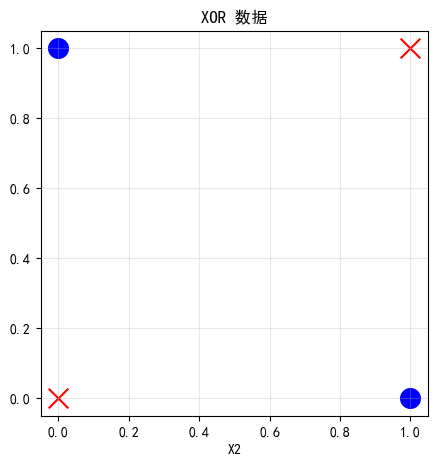

In [26]:
X = np.array([[0, 0], [0,1], [1,0], [1, 1]])

y = np.array([[0], [1], [1], [0]])

# 可视化 XOR 数据
plt.figure(figsize = (5, 5))
for i in range(len(X)):
    if(y[i] == 0):
        plt.scatter(X[i, 0], X[i, 1], c = 'red', marker = 'x', s = 200)
    else:
        plt.scatter(X[i, 0], X[i, 1], c = 'blue', marker = 'o', s = 200)

plt.xlabel('X1')
plt.xlabel('X2')
plt.title('XOR 数据')
plt.grid(alpha = 0.3)
plt.show()


##### ④ 训练 MLP

In [39]:
# 输入 2 维，隐藏层 2 个神经元，输出 1 维
mlp = MLP(input_size = 2, hidden_size = 2, output_size = 1, lr = 0.5)
mlp.fit(X, y, epochs = 10000)

Epoch 0, Loss: 0.7159
Epoch 500, Loss: 0.6636
Epoch 1000, Loss: 0.0903
Epoch 1500, Loss: 0.0291
Epoch 2000, Loss: 0.0168
Epoch 2500, Loss: 0.0117
Epoch 3000, Loss: 0.0090
Epoch 3500, Loss: 0.0073
Epoch 4000, Loss: 0.0061
Epoch 4500, Loss: 0.0052
Epoch 5000, Loss: 0.0046
Epoch 5500, Loss: 0.0041
Epoch 6000, Loss: 0.0037
Epoch 6500, Loss: 0.0034
Epoch 7000, Loss: 0.0031
Epoch 7500, Loss: 0.0028
Epoch 8000, Loss: 0.0026
Epoch 8500, Loss: 0.0025
Epoch 9000, Loss: 0.0023
Epoch 9500, Loss: 0.0022


##### ⑤ 绘制损失曲线

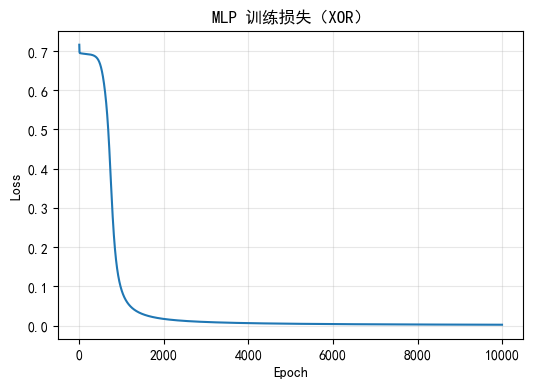

In [40]:
plt.figure(figsize=(6,4))
plt.plot(mlp.losses)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('MLP 训练损失（XOR）')
plt.grid(alpha=0.3)
plt.show()

##### ⑥ 查看预测结果

In [41]:
print("输出概率:\n", mlp.forward(X))
predictions = mlp.predict(X)
print("预测结果:\n", predictions.flatten())
print("真实标签:\n", y.flatten())
print("准确率:", np.mean(predictions == y))

输出概率:
 [[0.0024086 ]
 [0.99815496]
 [0.99816071]
 [0.00211786]]
预测结果:
 [0 1 1 0]
真实标签:
 [0 1 1 0]
准确率: 1.0


##### ⑦绘制决策边界

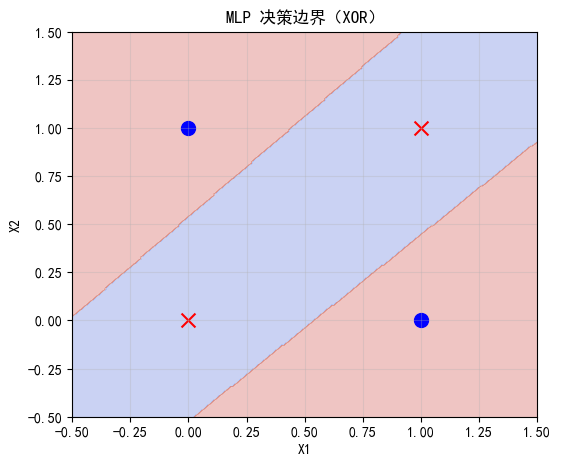

In [42]:
def plot_decision_boundary_mlp(model, X, y):
    x_min, x_max = -0.5, 1.5
    y_min, y_max = -0.5, 1.5
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))
    grid = np.c_[xx.ravel(), yy.ravel()]
    Z = model.predict(grid)
    Z = Z.reshape(xx.shape)

    plt.figure(figsize=(6,5))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[y.flatten()==0,0], X[y.flatten()==0,1], c='red', marker='x', s=100)
    plt.scatter(X[y.flatten()==1,0], X[y.flatten()==1,1], c='blue', marker='o', s=100)
    plt.xlabel('X1')
    plt.ylabel('X2')
    plt.title('MLP 决策边界（XOR）')
    plt.grid(alpha=0.3)
    plt.show()

plot_decision_boundary_mlp(mlp, X, y)